### APS1070 Project 3 - Part 1, Git Practice

**Academic Integrity**

This project is individual - it is to be completed on your own. If you have questions, please post your query in the APS1070 Piazza Q&A forums (the answer might be useful to others!).

Do not share your code with others, or post your work online. Do not submit code that you have not written yourself. Students suspected of plagiarism on a project, midterm or exam will be referred to the department for formal discipline for breaches of the Student Code of Conduct.

Please fill out the following:


*   Your **name**: Xinlong Ying
*   Your **student number**: 1005489446



## Part 1: Getting started with GitHub [1.5 Marks + 2 Mark Git Submission]


For the first four parts (Part 1-4) of this project, we will work on a [population of countries dataset](https://ourworldindata.org/grapher/population) which reports the population of over 200 countries worldwide from 10000 BCE to 2023. Download the dataset in .csv format using the provided code below. Using the Pandas package, create a population dataframe with only the countries provided in [this GitHub list](https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt) (237 countries - you should remove all other entities) as rows and years from 1901 to 2023 (123 years) as columns. Then, remove all the countries that have at least missing or invalid value over the years.

In [1]:
import pandas as pd
import requests, io

headers = {"User-Agent": "Mozilla/5.0"}
raw_data = pd.read_csv(
    filepath_or_buffer=io.StringIO(requests.get(
        'https://ourworldindata.org/grapher/population.csv?v=1&csvType=full&useColumnShortNames=true',
        headers=headers).text),
    index_col=False)

countries_list_url = "https://raw.githubusercontent.com/Sabaae/Dataset/main/countries_list.txt"

In [2]:
### YOUR CODE HERE ###
import numpy as np
import matplotlib.pyplot as plt

# read the list of 237 countries we are allowed to keep
countries = pd.read_csv(countries_list_url, header=None, names=['country'])['country'].str.strip().tolist()
print(f"Countries in the provided list: {len(countries)}")

# find the population column (its exact short name can change)
pop_col = [c for c in raw_data.columns if c.startswith('population')][0]

# keep only the listed countries, pivot so rows = countries and columns = years 1901-2023
df = (raw_data[raw_data['entity'].isin(countries)]
        .pivot(index='entity', columns='year', values=pop_col)
        .reindex(columns=range(1901, 2024)))

# turn invalid entries (non-numeric or <= 0 populations) into NaN,
# then drop any country that has at least one missing/invalid value
df = df.apply(pd.to_numeric, errors='coerce')
df = df.where(df > 0)
df = df.dropna()
df.index.name = 'country'

print(f"Final dataframe: {df.shape[0]} countries x {df.shape[1]} years")
df.head()

Countries in the provided list: 237
Final dataframe: 196 countries x 123 years


year,1901,1902,1903,1904,1905,1906,1907,1908,1909,1910,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
country,,,,,,,,,,,,,,,,,,,,,
Afghanistan,4751177.0,4802500.0,4861833.0,4921891.0,4982681.0,5044212.0,5106495.0,5169536.0,5300178.0,5504191.0,...,32792528.0,33831767.0,34700613.0,35688941.0,36743040.0,37856125.0,39068977.0,40000410.0,40578847.0,41454762.0
Albania,813539.0,821036.0,828461.0,835954.0,843514.0,851143.0,858841.0,866609.0,874016.0,881057.0,...,2903748.0,2898634.0,2897868.0,2898245.0,2894229.0,2885011.0,2871950.0,2849641.0,2827614.0,2811660.0
Algeria,4787149.0,4859600.0,4939332.0,5020372.0,5102742.0,5186463.0,5271557.0,5358048.0,5433528.0,5497750.0,...,39205035.0,40019528.0,40850719.0,41689302.0,42505033.0,43294551.0,44042094.0,44761099.0,45477391.0,46164222.0
Andorra,4551.0,4581.0,4610.0,4640.0,4670.0,4700.0,4730.0,4761.0,4802.0,4855.0,...,73755.0,72195.0,72197.0,73780.0,75181.0,76492.0,77397.0,78379.0,79722.0,80869.0
Angola,3083888.0,3064493.0,3043335.0,3022320.0,3001447.0,2980714.0,2960121.0,2939666.0,2921666.0,2906100.0,...,27160767.0,28157802.0,29183072.0,30234836.0,31297160.0,32375633.0,33451139.0,34532427.0,35635028.0,36749909.0


1. Write a function to do the following: **[0.5]**
    * Takes the dataframe, and your list of countries/regions as inputs (Afghanistan, Albania, Algeria, ...)
    * Plots time-series for the input list (it is best to plot each country in a separate graph (subplot), so you can easily compare them.)
    
2. Apply `StandardScalar` to the data. Each year should have a `mean` of zero and a `StD` of 1. **[0.25]**
3. Pick two countries whose names are closest to your first name using string edit distance.
Hint: you can use `Levenshtein.distance()` from the python-Levenshtein package. You may find [this link](https://www.geeksforgeeks.org/python/introduction-to-python-levenshtein-module/) helpful.
4. Run the function in `step 1` on both the original as well as the standardized dataset for the two countries you picked in `step 3` plus `Japan`, `Bosnia and Herzegovina`, `Latvia`, and `United Arab Emirates`. (If you have already selected one of these countries, go down the list and pick the next one you haven't selected) **[0.25]**
5. Discuss the trends in the standardized time-series for all these countries. What does it mean if the curve goes up or down? What does the sign of values indicate? **[0.5]**

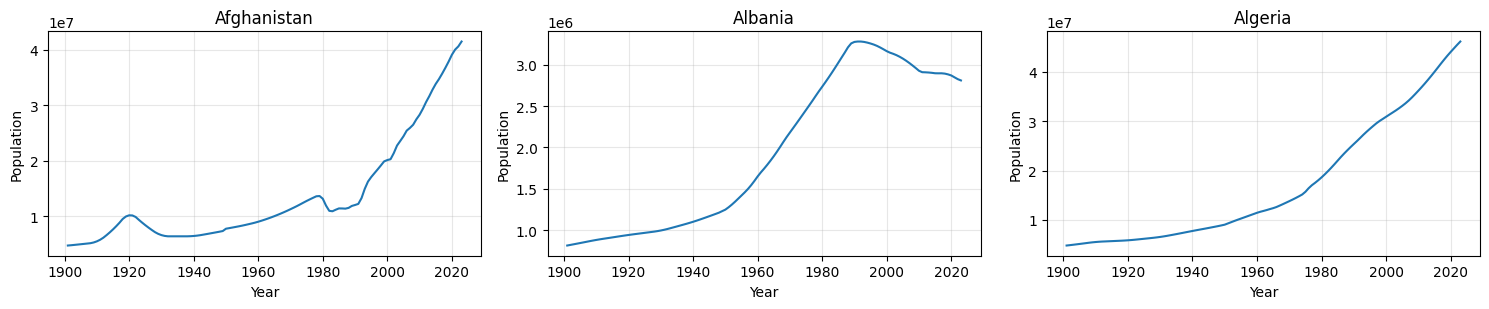

In [3]:
def plot_countries(data, country_list, ylabel='Population'):
    """Plot the time-series of each country in country_list as its own subplot."""
    n = len(country_list)
    ncols = 3
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3.2 * nrows), squeeze=False)
    for i, country in enumerate(country_list):
        ax = axes[i // ncols][i % ncols]
        ax.plot(data.columns, data.loc[country])
        ax.set_title(country)
        ax.set_xlabel('Year')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
    for j in range(n, nrows * ncols):          # hide unused axes
        axes[j // ncols][j % ncols].axis('off')
    fig.tight_layout()
    plt.show()

# quick demo
plot_countries(df, df.index[:3].tolist())

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_std = pd.DataFrame(scaler.fit_transform(df), index=df.index, columns=df.columns)

# verify: every year (column) should now have mean ~0 and std ~1
print("max |mean| over years :", df_std.mean(axis=0).abs().max())
print("max |std - 1| over years:", (df_std.std(axis=0, ddof=0) - 1).abs().max())

max |mean| over years : 4.531522549490435e-17
max |std - 1| over years: 7.771561172376096e-16


In [5]:
!pip install python-Levenshtein -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.3/153.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 49.0 MB/s eta 0:00:00


In [6]:
import Levenshtein

my_name = 'Xinlong'
# stable sort keeps ties in alphabetical order, so the result is reproducible
distances = pd.Series({c: Levenshtein.distance(my_name, c) for c in df.index},
                      name='edit distance to ' + my_name).sort_values(kind='stable')
print(distances.head(8))

required = ['Japan', 'Bosnia and Herzegovina', 'Latvia', 'United Arab Emirates']
# two closest countries, skipping any that are already in the required list
closest_two = [c for c in distances.index if c not in required][:2]
print("\nSelected countries:", closest_two)

selected = closest_two + required

Finland      3
Angola       5
Benin        5
Congo        5
Gabon        5
Hong Kong    5
Iceland      5
Poland       5
Name: edit distance to Xinlong, dtype: int64

Selected countries: ['Finland', 'Angola']


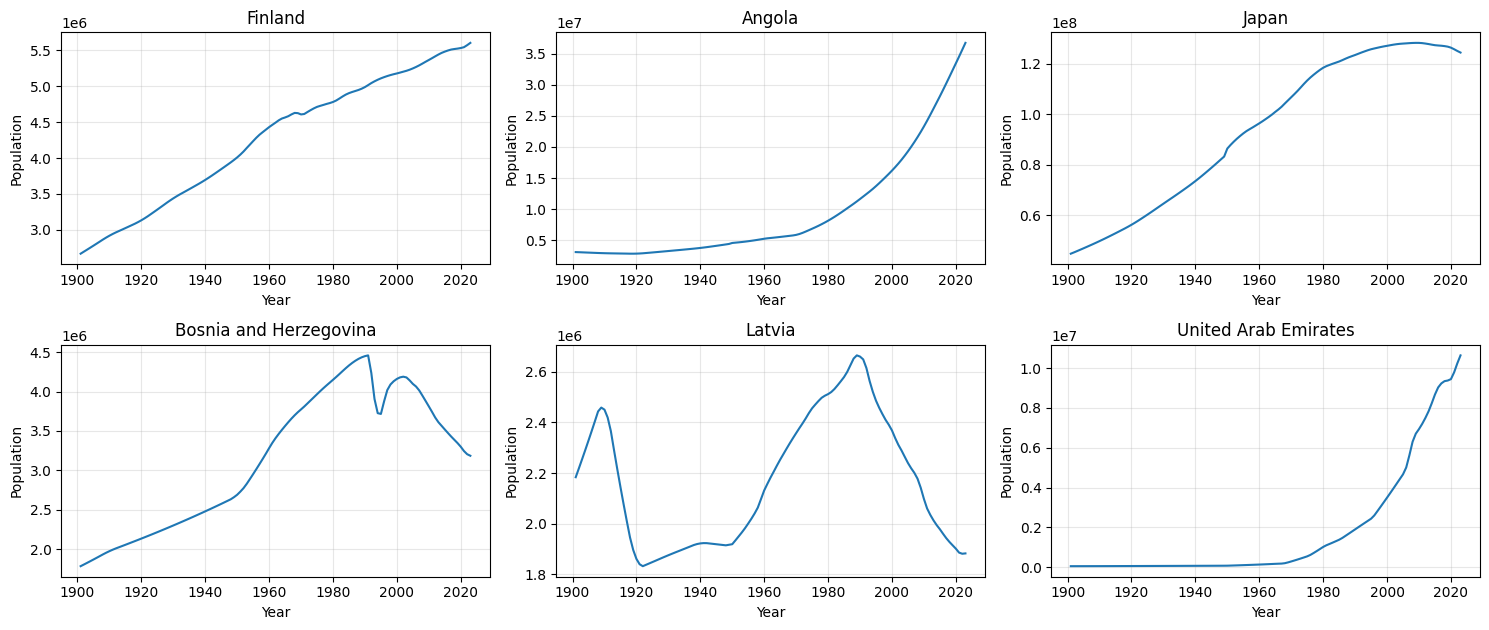

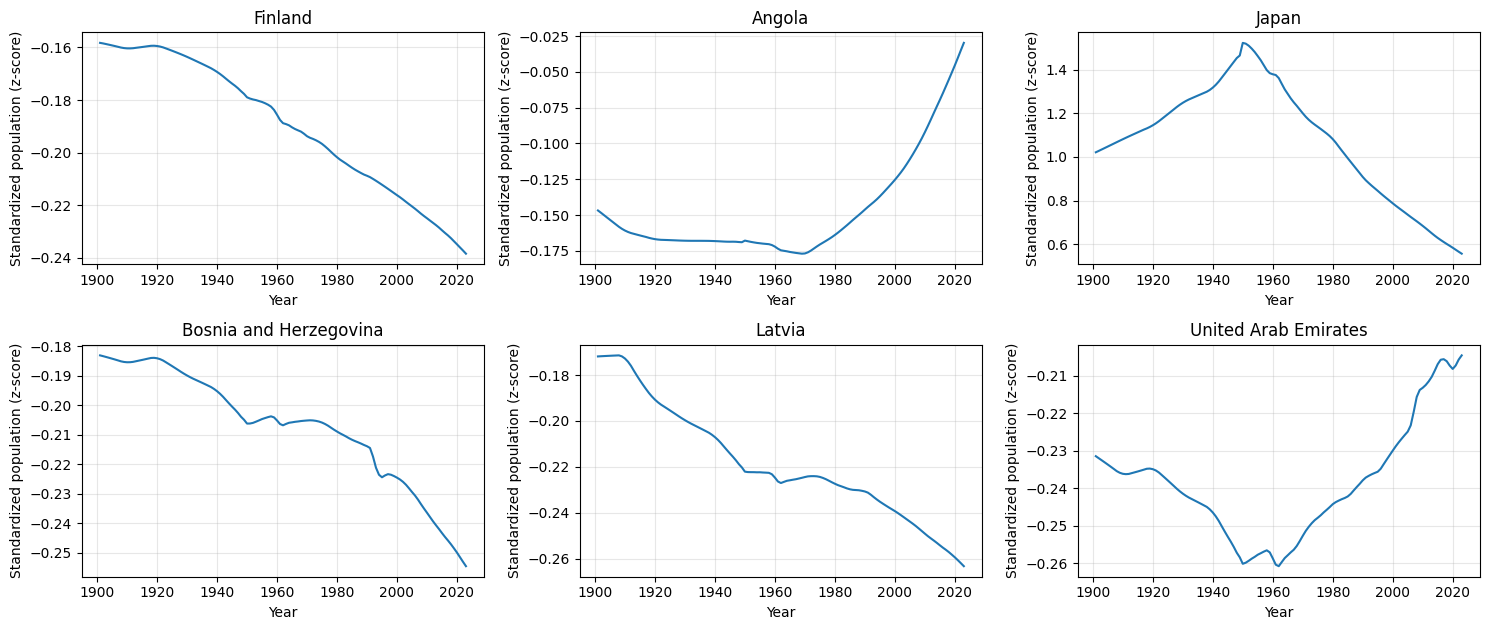

In [7]:
plot_countries(df, selected, ylabel='Population')
plot_countries(df_std, selected, ylabel='Standardized population (z-score)')

#### Step 5 — Discussion

The standardization is done per year, so each value shows where a country sits compared to all the other countries in that same year. A positive value means the country is above the average country that year, negative means below it. A few giants (China, India, the US) drag the average way up, so most countries sit a bit below zero — that is why only Japan is positive here. A curve going up means the country is growing faster than the rest of the world (gaining relative position), and going down means growing slower or shrinking. A country can grow in absolute terms and still trend down.

* **Japan**: positive the whole time, but falls in recent decades — its population peaked around 2009 and is now shrinking.
* **Finland**: negative and slowly drifting down. It only grew about 2x in 123 years, slower than the world overall.
* **Angola**: negative, then rises steeply after the 1970s (about 12x growth overall), ending near the average.
* **Bosnia and Herzegovina**: negative, with a sharp dip during the 1992-95 war, and falling since the early 2000s.
* **Latvia**: negative and falling — a WWI dip early on, then steady decline since 1990.
* **UAE**: negative and flat until about 1970, then it shoots up after the oil boom.